# Bounding-box tightening — demo walkthrough, updated for `tightened_template_box()`

> **This is the corrected re-run of [`bbox_tuning_walkthrough.ipynb`](../bbox_tuning_walkthrough.ipynb).**
> That notebook only ever called `seed_selection.tighten_box_otsu` (the patch-local Otsu box)
> and `tightened_base_size` (that box's size, kept **click-centred**) — it never called
> `tightened_template_box`, not because of any bug but because it's an older, narrower demo that
> predates that line of work. `tightened_template_box` already existed, uncommitted, in
> `midog_utils/seed_selection.py` before today, called by the four `production_seed_precision_at_k*`
> notebooks with a buggy centre formula; it was committed to git for the first time on 2026-09-10
> (commit `ddaf049`, `D8_TEMPLATE_ANCHOR.md`), which is also when that formula was fixed: the
> accepted component's own bounding-box centre — not the click — anchors the template, computed
> as `(x0 + x1 - 1) / 2` rather than the previous `(x0 + x1) / 2`.
>
> Same annotation (`002.tiff`, `ann_id=10`) and the same seven-domain sample as the original.
> Steps 1-6 below reproduce that notebook's preprocessing walkthrough unchanged —
> `tighten_box_otsu`'s internals didn't move. Step 7 is the original notebook's ending
> (click-centred box). **Step 8 onward is new**: it places the tightened box three ways —
> click-centred, the previous buggy recentred formula, and the corrected one — and measures how
> far apart they land, both for this one annotation and across the domain sample.
>
> The largest-connected-component alternative the original notebook built in its final third is
> orthogonal to this fix and isn't reproduced here; see the original for that.

## Picking one annotation to walk through

`002.tiff` (human breast cancer) is the same sample image used throughout
`Research Logs/`. Annotation `ann_id=10` is a clean, non-border-touching mitotic
figure — a representative case for the full step-by-step below. (A case the method
*rejects* is shown separately, further down.)

numpy 1.26.4 | opencv 4.8.1


002.tiff ann 10: click at (cx=6267, cy=3218), ROI shape (5412, 7215, 3)


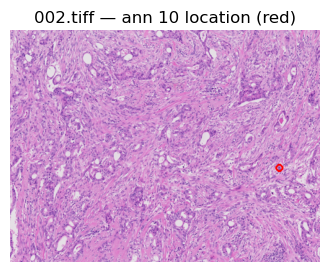

In [1]:
import sys
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from skimage.measure import label, regionprops

sys.path.insert(0, '..')
from midog_utils import dataset, channels, template_match as tm, seed_selection as ss

print("numpy", np.__version__, "| opencv", cv2.__version__)

IMAGES_DIR = Path("..") / "images"
images, anns = dataset.load_annotations("../databases/MIDOG++.json")
Path("debug_pics").mkdir(exist_ok=True)  # every debug image this notebook saves lands here

FNAME = "002.tiff"
ANN_ID = 10

rgb = dataset.load_roi(IMAGES_DIR / FNAME)
mit = dataset.image_annotations(anns, FNAME, category_id=1)
row = mit[mit["ann_id"] == ANN_ID].iloc[0]
cx, cy = float(row["cx"]), float(row["cy"])
print(f"{FNAME} ann {ANN_ID}: click at (cx={cx:.0f}, cy={cy:.0f}), ROI shape {rgb.shape}")

thumb = Image.fromarray(rgb).copy()
thumb.thumbnail((500, 500))
scale = thumb.width / rgb.shape[1]
draw = ImageDraw.Draw(thumb)
r = 6
draw.ellipse([cx * scale - r, cy * scale - r, cx * scale + r, cy * scale + r], outline="red", width=3)
plt.figure(figsize=(4, 4))
plt.imshow(thumb)
plt.title(f"{FNAME} — ann {ANN_ID} location (red)")
plt.axis("off")
plt.show()

## Step 1 — read a padded patch around the click

`template_match.read_padded_patch` crops a square window centred on `(cx, cy)`.
Bbox tightening uses the **annotation-box-sized** window (`template_match.BASE_SIZE`,
51px — the 50x50 box made odd so the click lands exactly on the centre pixel), not the
wider rotation-safe `PATCH_SIZE` window used later for template matching itself:
a wider window lets Otsu bridge into neighbouring nuclei in dense tissue
(`foreground_filter`'s docstring, calibrated on `246.tiff`).

rgb_patch shape: (51, 51, 3) uint8


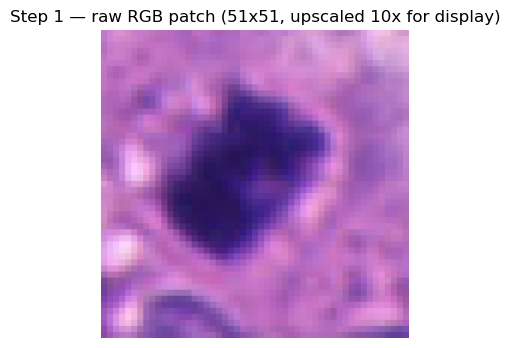

In [2]:
def upscale(arr_or_img, factor=10):
    im = arr_or_img if isinstance(arr_or_img, Image.Image) else Image.fromarray(arr_or_img)
    return im.resize((im.width * factor, im.height * factor), Image.NEAREST)

SCALE = 10  # for display only -- the patch itself stays BASE_SIZE x BASE_SIZE

rgb_patch = tm.read_padded_patch(rgb, cx, cy, tm.BASE_SIZE)
print("rgb_patch shape:", rgb_patch.shape, rgb_patch.dtype)

plt.figure(figsize=(4, 4))
plt.imshow(upscale(rgb_patch, SCALE))
plt.title(f"Step 1 — raw RGB patch ({tm.BASE_SIZE}x{tm.BASE_SIZE}, upscaled {SCALE}x for display)")
plt.axis("off")
plt.show()

## Step 2 — grayscale, then invert (`channels.to_gray_inverted`)

Seed selection's structural channel is **always** `gray_inverted`, independent of
whatever channel the later template search uses (`experiment.py`) — chosen because
Otsu/connected-components just needs a stable "object vs. background" contrast map,
not a stain-selective one.

H&E stains chromatin *dark* on a lighter pink/purple background. Otsu and connected
components below both operate on a "more object -> higher value" convention, so the
grayscale value is inverted (`255 - gray`) — the dense, dark nucleus becomes the
*bright* region the rest of the pipeline looks for.

inverted patch matches channels.to_gray_inverted(rgb) exactly


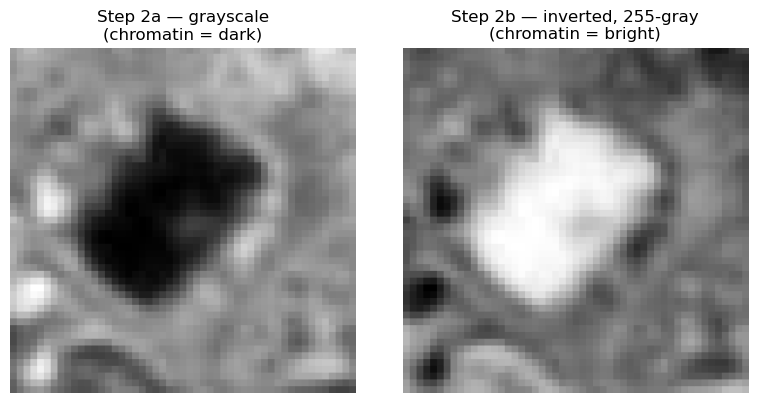

In [3]:
gray_patch = cv2.cvtColor(rgb_patch, cv2.COLOR_RGB2GRAY)
inverted_patch = 255.0 - gray_patch.astype(np.float32)

# Sanity check: this is exactly what channels.to_gray_inverted(rgb) gives when cropped
# the same way -- confirms the manual steps below track the real channel function.
structural = channels.to_gray_inverted(rgb)
patch = tm.read_padded_patch(structural, cx, cy, tm.BASE_SIZE)
assert np.allclose(inverted_patch, patch)
print("inverted patch matches channels.to_gray_inverted(rgb) exactly")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(upscale(gray_patch, SCALE), cmap="gray")
axes[0].set_title("Step 2a — grayscale\n(chromatin = dark)")
axes[0].axis("off")
axes[1].imshow(upscale(inverted_patch.astype(np.uint8), SCALE), cmap="gray")
axes[1].set_title("Step 2b — inverted, 255-gray\n(chromatin = bright)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Step 3 — normalize to uint8

`tighten_box_otsu` rescales the patch's own min-max range to the full `0-255` `uint8`
range (`cv2.normalize(..., cv2.NORM_MINMAX)`) before thresholding. This is a per-patch
rescale, distinct from `channels.to_hematoxylin`'s ROI-wide percentile rescale — it
just gives Otsu (which expects `uint8`) full use of the range within *this* small crop.

before: [27.0, 222.0]  ->  after: [0, 255]


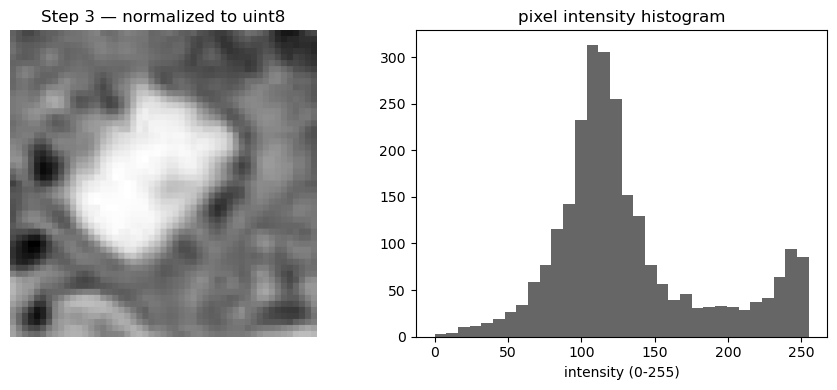

In [4]:
u8 = cv2.normalize(patch.astype(np.float32), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
print(f"before: [{patch.min():.1f}, {patch.max():.1f}]  ->  after: [{u8.min()}, {u8.max()}]")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(upscale(u8, SCALE), cmap="gray")
axes[0].set_title("Step 3 — normalized to uint8")
axes[0].axis("off")
axes[1].hist(u8.ravel(), bins=32, color="0.4")
axes[1].set_title("pixel intensity histogram")
axes[1].set_xlabel("intensity (0-255)")
plt.tight_layout()
plt.show()

## Step 4 — Otsu threshold

`cv2.threshold(..., cv2.THRESH_BINARY + cv2.THRESH_OTSU)` picks the intensity value
that best splits the patch's own histogram into two classes (foreground/background) —
no hand-tuned relative threshold, unlike the 1D cross-profile method this replaced
(`Research Logs/2026-08-25-bbox-tuning-domain-mismatch.md`, experiments 1-3).

Otsu threshold: 163/255  |  foreground pixels: 545/2601 (21%)


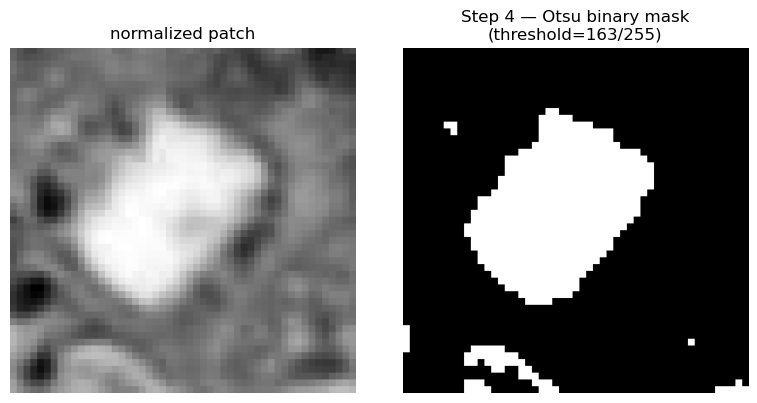

In [5]:
otsu_thresh, binary = cv2.threshold(u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
n_fg = int((binary > 0).sum())
print(f"Otsu threshold: {otsu_thresh:.0f}/255  |  foreground pixels: {n_fg}/{binary.size} ({100*n_fg/binary.size:.0f}%)")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(upscale(u8, SCALE), cmap="gray")
axes[0].axhline(0, color="none")
axes[0].set_title("normalized patch")
axes[0].axis("off")
axes[1].imshow(upscale(binary, SCALE), cmap="gray")
axes[1].set_title(f"Step 4 — Otsu binary mask\n(threshold={otsu_thresh:.0f}/255)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Step 5 — connected-component labeling

`skimage.measure.label(binary, connectivity=2)` (8-connectivity) separates the binary
mask into individually numbered blobs. A different, non-touching dark nucleus
elsewhere in the crop becomes its own label and is automatically excluded from
whatever gets picked next — no explicit "ignore other nuclei" logic needed.

Step 5 — 7 connected component(s) found in this patch


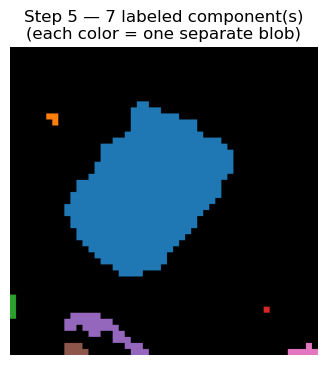

In [6]:
labels_arr = label(binary, connectivity=2)
n_components = int(labels_arr.max())
print(f"Step 5 — {n_components} connected component(s) found in this patch")

cmap = plt.get_cmap("tab10")
label_rgb = np.zeros((*labels_arr.shape, 3), dtype=np.uint8)
for lbl in range(1, n_components + 1):
    color = (np.array(cmap((lbl - 1) % 10)[:3]) * 255).astype(np.uint8)
    label_rgb[labels_arr == lbl] = color

plt.figure(figsize=(4, 4))
plt.imshow(upscale(label_rgb, SCALE))
plt.title(f"Step 5 — {n_components} labeled component(s)\n(each color = one separate blob)")
plt.axis("off")
plt.show()

## Step 6 — select the component under the click, then sanity-check it

The click is always the patch's centre pixel (the annotation box is built as
`point ± 25`, and the window here is that same box). Whichever labeled component sits
under that pixel is the candidate; if the centre pixel is background (`label == 0`),
`tighten_box_otsu` returns `None` rather than falling back to "the biggest blob in the
crop" — see the rejected-example section below for why.

An accepted component still has to pass three sanity checks
(`seed_selection.tighten_box_otsu`, `Research Logs/design_choices.md` section 2):

- `min_area=50` — rejects a degenerate sliver.
- `max_area_frac=0.85` of the window's pixel count — rejects a component that has
  grown implausibly large (bridged into a neighbour).
- `min_solidity=0.5` (filled area / convex-hull area) — rejects a concave,
  dumbbell-shaped merge of two touching nuclei; a real elongated mitotic figure stays
  convex enough to pass.

centre pixel (25, 25) has label 1


component area=490px  solidity=0.93  bbox=(9, 9, 38, 37)
  [PASS] min_area (>= 50)
  [PASS] max_area_frac (<= 0.85 * window)
  [PASS] min_solidity (>= 0.5)


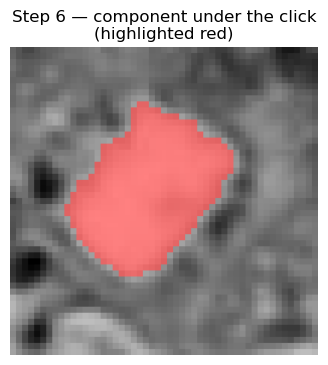

In [7]:
cy_p, cx_p = patch.shape[0] // 2, patch.shape[1] // 2
center_label = labels_arr[cy_p, cx_p]
print(f"centre pixel ({cx_p}, {cy_p}) has label {center_label}")

region = next(p for p in regionprops(labels_arr) if p.label == center_label)
min_row, min_col, max_row, max_col = region.bbox

checks = {
    "min_area (>= 50)": region.area >= 50,
    "max_area_frac (<= 0.85 * window)": region.area <= 0.85 * patch.size,
    "min_solidity (>= 0.5)": region.solidity >= 0.5,
}
print(f"component area={region.area:.0f}px  solidity={region.solidity:.2f}  bbox={region.bbox}")
for name, passed in checks.items():
    print(f"  [{'PASS' if passed else 'FAIL'}] {name}")

mask = labels_arr == center_label
overlay = np.stack([u8, u8, u8], axis=-1).copy()
overlay[mask] = (overlay[mask] * 0.35 + np.array([255, 60, 60]) * 0.65).astype(np.uint8)
plt.figure(figsize=(4, 4))
plt.imshow(upscale(overlay, SCALE))
plt.title("Step 6 — component under the click\n(highlighted red)")
plt.axis("off")
plt.show()

## Step 7 — final tightened box, click-centred (the original notebook's ending)

The selected component's bounding box (`skimage`'s `region.bbox`, already
`(min_row, min_col, max_row, max_col)`, half-open) *is* the tightened box, in
patch-local coordinates. Below: overlay the original 50x50 annotation box (yellow)
against the tightened box (red), first on the small patch, then mapped back onto the
full-resolution ROI — and confirm this manual, step-by-step result is bit-for-bit what
`seed_selection.tighten_box_otsu` returns when called directly on the same patch.

This is where the original walkthrough stopped: the box is sized from the component,
but still drawn **centred on the click** (`tightened_base_size`, click-centred by
design — see its docstring). Step 8 below is what changes.

manual result:    (9, 38, 9, 37)
tighten_box_otsu: (9, 38, 9, 37)
-> identical: this walkthrough matches the production function exactly.

original annotation box: 50x50 (synthetic, point +/- 25)
tightened box:           28x29, offset (9,9) within the patch
(both drawn against the 51x51 Otsu window the tightening itself used)

tightened_base_size() -> 29px (odd, longer side of the tightened box) -- click-centred, feeds FSConfig(base_size=...)


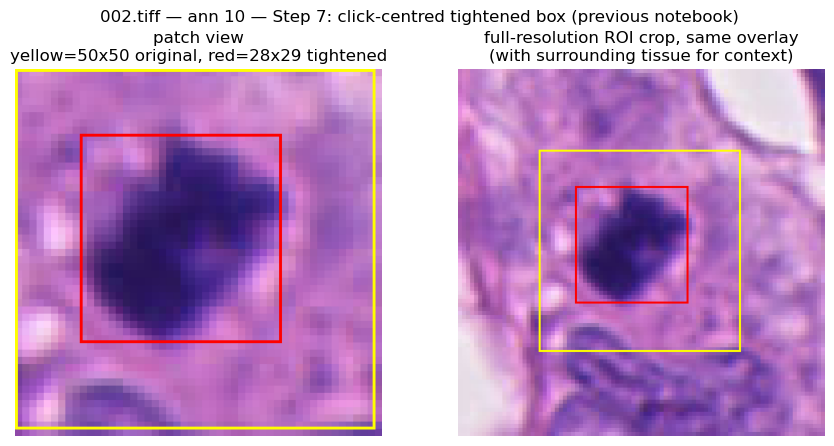

In [8]:
manual_box = (int(min_row), int(max_row), int(min_col), int(max_col))  # (y0, y1, x0, x1)
prod_box = ss.tighten_box_otsu(patch)
print("manual result:   ", manual_box)
print("tighten_box_otsu:", prod_box)
assert manual_box == prod_box
print("-> identical: this walkthrough matches the production function exactly.\n")

y0, y1, x0, x1 = manual_box
w_new, h_new = x1 - x0, y1 - y0

# The *true* synthetic annotation box is 50x50 (point +/- 25) -- distinct from the
# 51x51 Otsu window (BASE_SIZE, made odd so the click is exactly the centre pixel).
# Map it into patch-local coordinates from the patch's own origin in full-ROI space.
patch_half = tm.BASE_SIZE // 2
patch_origin_x, patch_origin_y = round(cx) - patch_half, round(cy) - patch_half
ann_w, ann_h = float(row["w"]), float(row["h"])
ann_x0 = (cx - ann_w / 2) - patch_origin_x
ann_y0 = (cy - ann_h / 2) - patch_origin_y
ann_x1, ann_y1 = ann_x0 + ann_w, ann_y0 + ann_h

print(f"original annotation box: {ann_w:.0f}x{ann_h:.0f} (synthetic, point +/- 25)")
print(f"tightened box:           {w_new}x{h_new}, offset ({x0},{y0}) within the patch")
print(f"(both drawn against the {tm.BASE_SIZE}x{tm.BASE_SIZE} Otsu window the tightening itself used)")

base_size = ss.tightened_base_size(structural, cx, cy)
print(f"\ntightened_base_size() -> {base_size}px "
      f"(odd, longer side of the tightened box) -- click-centred, feeds FSConfig(base_size=...)")

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))

im_patch = upscale(Image.fromarray(rgb_patch), SCALE)
d = ImageDraw.Draw(im_patch)
d.rectangle([ann_x0 * SCALE, ann_y0 * SCALE, ann_x1 * SCALE, ann_y1 * SCALE], outline="yellow", width=4)
d.rectangle([x0 * SCALE, y0 * SCALE, x1 * SCALE, y1 * SCALE], outline="red", width=4)
axes[0].imshow(im_patch)
axes[0].set_title(f"patch view\nyellow={ann_w:.0f}x{ann_h:.0f} original, red={w_new}x{h_new} tightened")
axes[0].axis("off")

margin = 20
full_x0, full_y0 = int(cx - tm.BASE_SIZE // 2 - margin), int(cy - tm.BASE_SIZE // 2 - margin)
full_size = tm.BASE_SIZE + 2 * margin
crop_full = rgb[full_y0:full_y0 + full_size, full_x0:full_x0 + full_size]
im_full = upscale(Image.fromarray(crop_full), 6)
d2 = ImageDraw.Draw(im_full)
offset_x, offset_y = patch_origin_x - full_x0, patch_origin_y - full_y0
d2.rectangle([(offset_x + ann_x0) * 6, (offset_y + ann_y0) * 6, (offset_x + ann_x1) * 6, (offset_y + ann_y1) * 6], outline="yellow", width=3)
d2.rectangle([(offset_x + x0) * 6, (offset_y + y0) * 6, (offset_x + x1) * 6, (offset_y + y1) * 6], outline="red", width=3)
axes[1].imshow(im_full)
axes[1].set_title("full-resolution ROI crop, same overlay\n(with surrounding tissue for context)")
axes[1].axis("off")

fig.suptitle(f"{FNAME} — ann {ANN_ID} — Step 7: click-centred tightened box (previous notebook)", fontsize=12)
plt.tight_layout()
plt.savefig("debug_pics/bbox_tuning_updated_step7_click_centred.png", dpi=130)
plt.show()

## Step 8 (new) — where `tightened_template_box()` actually places this box

Step 7's red box has the right *size* but is still anchored on the click. `tightened_template_box`
keeps the same containment gate (the click must land inside the accepted component, unchanged) but
moves the box's **centre** to the component's own bounding-box centre — the point `tighten_box_otsu`
already measured and Step 7 discarded.

Three centres for this one annotation, all in full-ROI pixel coordinates:

1. **click-centred** — `(cx, cy)`, what Step 7 drew.
2. **old buggy recentre** — `(x0 + x1) / 2`, the formula `tightened_template_box` used before
   today. It no longer exists anywhere in `seed_selection.py`; it's reconstructed inline below,
   from the same `(y0, y1, x0, x1)` bbox, purely for this comparison.
3. **new fixed recentre** — `(x0 + x1 - 1) / 2`, what `ss.tightened_template_box` returns now.

`D8_TEMPLATE_ANCHOR.md`'s guarantee: a `base_size`-square centred on anchor 3 always contains the
whole accepted component; anchors 1 and 2 are not guaranteed to.

base_size: 29px (same value tightened_base_size gave in Step 7: 29)

anchor                          centre (x, y)           contains whole component
click-centred (Step 7)          (6267.00, 3218.00)        False
old buggy recentre (x0+x1)/2    (6265.00, 3216.50)        True
new fixed recentre (x0+x1-1)/2  (6264.50, 3216.00)        True

drift, click -> new fixed centre:      3.20px
drift, old buggy -> new fixed centre:  0.71px


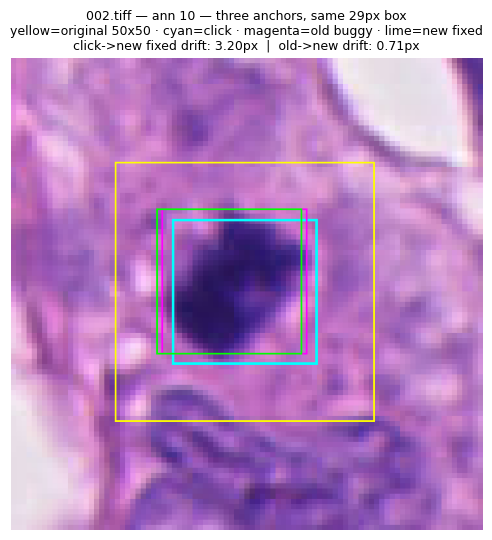

In [9]:
def old_buggy_center(cx, cy, bbox, otsu_window=tm.BASE_SIZE):
    """The pre-2026-09-10 `tightened_template_box` centre formula, (x0+x1)/2 -- reconstructed
    here purely for comparison. It no longer exists in `seed_selection` after commit ddaf049."""
    y0, y1, x0, x1 = bbox
    half = otsu_window // 2
    ix, iy = int(round(cx)), int(round(cy))
    return ix - half + (x0 + x1) / 2.0, iy - half + (y0 + y1) / 2.0


def component_full_bbox(cx, cy, bbox, otsu_window=tm.BASE_SIZE):
    """The accepted component's own bbox, mapped from patch-local to full-ROI pixel coords.
    Half-open in both axes, same convention as `region.bbox` / `tighten_box_otsu`."""
    y0, y1, x0, x1 = bbox
    half = otsu_window // 2
    ix, iy = int(round(cx)), int(round(cy))
    return (ix - half + x0, ix - half + x1, iy - half + y0, iy - half + y1)  # (cx0, cx1, cy0, cy1)


def contains_component(center, base_size, comp_full):
    """Would a `base_size`-square centred on `center` (rounded the way `read_padded_patch`
    rounds it) contain every pixel of the accepted component?"""
    cx0, cx1, cy0, cy1 = comp_full
    half = base_size // 2
    icx, icy = int(round(center[0])), int(round(center[1]))
    return cx0 >= icx - half and (cx1 - 1) <= icx + half and cy0 >= icy - half and (cy1 - 1) <= icy + half


result = ss.tightened_template_box(structural, cx, cy)
assert result is not None, "tighten_box_otsu accepted this click but tightened_template_box refused it"
base_size_new, center_x_new, center_y_new = result

old_cx, old_cy = old_buggy_center(cx, cy, manual_box)
comp_full = component_full_bbox(cx, cy, manual_box)

click_ok = contains_component((cx, cy), base_size_new, comp_full)
old_ok = contains_component((old_cx, old_cy), base_size_new, comp_full)
new_ok = contains_component((center_x_new, center_y_new), base_size_new, comp_full)

drift_click_to_new = float(np.hypot(center_x_new - cx, center_y_new - cy))
drift_old_to_new = float(np.hypot(center_x_new - old_cx, center_y_new - old_cy))

print(f"base_size: {base_size_new}px (same value tightened_base_size gave in Step 7: {base_size})\n")
print(f"{'anchor':<32}{'centre (x, y)':<24}{'contains whole component'}")
print(f"{'click-centred (Step 7)':<32}({cx:.2f}, {cy:.2f}){'':<8}{click_ok}")
print(f"{'old buggy recentre (x0+x1)/2':<32}({old_cx:.2f}, {old_cy:.2f}){'':<8}{old_ok}")
print(f"{'new fixed recentre (x0+x1-1)/2':<32}({center_x_new:.2f}, {center_y_new:.2f}){'':<8}{new_ok}")
print(f"\ndrift, click -> new fixed centre:      {drift_click_to_new:.2f}px")
print(f"drift, old buggy -> new fixed centre:  {drift_old_to_new:.2f}px")

margin = 20
full_x0, full_y0 = int(cx - tm.BASE_SIZE // 2 - margin), int(cy - tm.BASE_SIZE // 2 - margin)
full_size = tm.BASE_SIZE + 2 * margin
crop_full = rgb[full_y0:full_y0 + full_size, full_x0:full_x0 + full_size]
im_full = upscale(Image.fromarray(crop_full), 6)
d3 = ImageDraw.Draw(im_full)
half_new = base_size_new // 2


def draw_centred_box(draw, cx_, cy_, half, color, width):
    icx, icy = int(round(cx_)) - full_x0, int(round(cy_)) - full_y0
    draw.rectangle([(icx - half) * 6, (icy - half) * 6, (icx + half) * 6, (icy + half) * 6],
                   outline=color, width=width)


d3.rectangle([(offset_x + ann_x0) * 6, (offset_y + ann_y0) * 6, (offset_x + ann_x1) * 6, (offset_y + ann_y1) * 6],
             outline="yellow", width=2)
draw_centred_box(d3, cx, cy, half_new, "cyan", 3)
draw_centred_box(d3, old_cx, old_cy, half_new, "magenta", 2)
draw_centred_box(d3, center_x_new, center_y_new, half_new, "lime", 2)

plt.figure(figsize=(5.5, 5.5))
plt.imshow(im_full)
plt.title(
    f"{FNAME} — ann {ANN_ID} — three anchors, same {base_size_new}px box\n"
    f"yellow=original 50x50 · cyan=click · magenta=old buggy · lime=new fixed\n"
    f"click->new fixed drift: {drift_click_to_new:.2f}px  |  old->new drift: {drift_old_to_new:.2f}px",
    fontsize=9,
)
plt.axis("off")
plt.tight_layout()
plt.savefig("debug_pics/bbox_tuning_updated_step8_three_anchors.png", dpi=130)
plt.show()

## A rejected example — the click sits outside its own object's mask

`ann_id=20` in the same image fails Step 6's centre-pixel check: the annotated point
sits right on the *edge* of the nucleus rather than solidly inside it, so after Otsu
thresholding the centre pixel itself is background. The production code **excludes**
the annotation from the candidate pool rather than guessing
(`Research Logs/design_choices.md` section 2). This gate is unchanged by the anchor fix:
`tightened_template_box` calls `tighten_box_otsu` with the same `center_tolerance=0`, so an
annotation Step 6 rejects stays rejected here too — there is no centre to recompute.

ann 20: centre-pixel label = 0 (0 = background)
tighten_box_otsu(patch)      -> None
tightened_template_box(...)  -> None


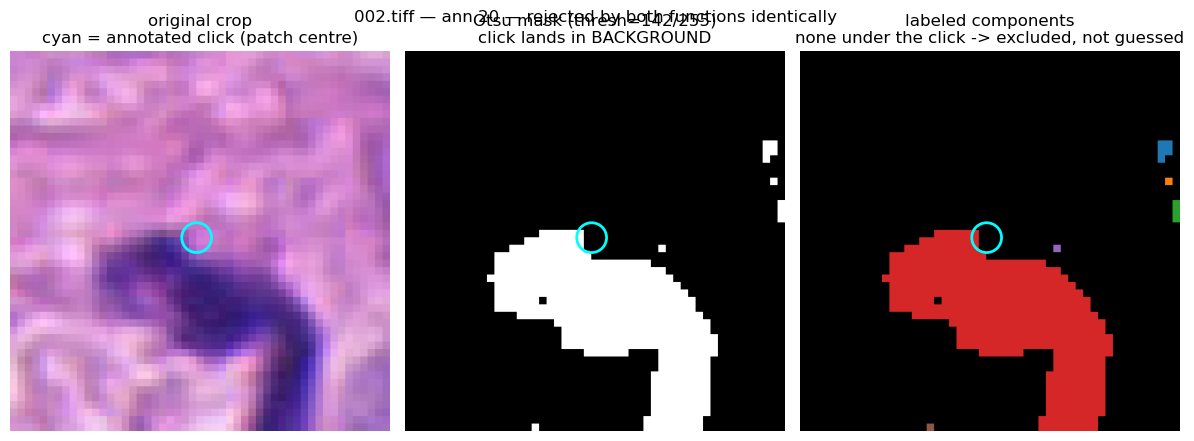

In [10]:
ANN_ID_REJECTED = 20
row_r = mit[mit["ann_id"] == ANN_ID_REJECTED].iloc[0]
cx_r, cy_r = float(row_r["cx"]), float(row_r["cy"])

rgb_patch_r = tm.read_padded_patch(rgb, cx_r, cy_r, tm.BASE_SIZE)
patch_r = tm.read_padded_patch(structural, cx_r, cy_r, tm.BASE_SIZE)
u8_r = cv2.normalize(patch_r.astype(np.float32), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
otsu_r, binary_r = cv2.threshold(u8_r, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
labels_r = label(binary_r, connectivity=2)
cy_pr, cx_pr = patch_r.shape[0] // 2, patch_r.shape[1] // 2
center_label_r = labels_r[cy_pr, cx_pr]

print(f"ann {ANN_ID_REJECTED}: centre-pixel label = {center_label_r} (0 = background)")
print("tighten_box_otsu(patch)      ->", ss.tighten_box_otsu(patch_r))
print("tightened_template_box(...)  ->", ss.tightened_template_box(structural, cx_r, cy_r))

fig, axes = plt.subplots(1, 3, figsize=(12, 4.5))
axes[0].imshow(upscale(rgb_patch_r, SCALE))
r_dot = 2
cxp, cyp = patch_r.shape[1] // 2, patch_r.shape[0] // 2
axes[0].add_patch(plt.Circle((cxp * SCALE, cyp * SCALE), r_dot * SCALE, fill=False, color="cyan", linewidth=2))
axes[0].set_title("original crop\ncyan = annotated click (patch centre)")
axes[0].axis("off")

axes[1].imshow(upscale(binary_r, SCALE), cmap="gray")
axes[1].add_patch(plt.Circle((cxp * SCALE, cyp * SCALE), r_dot * SCALE, fill=False, color="cyan", linewidth=2))
axes[1].set_title(f"Otsu mask (thresh={otsu_r:.0f}/255)\nclick lands in BACKGROUND")
axes[1].axis("off")

label_rgb_r = np.zeros((*labels_r.shape, 3), dtype=np.uint8)
cmap = plt.get_cmap("tab10")
for lbl in range(1, int(labels_r.max()) + 1):
    color = (np.array(cmap((lbl - 1) % 10)[:3]) * 255).astype(np.uint8)
    label_rgb_r[labels_r == lbl] = color
axes[2].imshow(upscale(label_rgb_r, SCALE))
axes[2].add_patch(plt.Circle((cxp * SCALE, cyp * SCALE), r_dot * SCALE, fill=False, color="cyan", linewidth=2))
axes[2].set_title("labeled components\nnone under the click -> excluded, not guessed")
axes[2].axis("off")

fig.suptitle(f"{FNAME} — ann {ANN_ID_REJECTED} — rejected by both functions identically", fontsize=12)
plt.tight_layout()
plt.show()

## Every domain: how far the box moves, sampled the same way as the original

Same seven MIDOG++ tumor-type domains, same one sample image and up to 9 mitotic annotations each
as the original notebook's domain sweep — but this time every *accepted* seed gets all three
anchors (click / old buggy / new fixed) and a containment check against the accepted component's
own bbox, so the single-annotation numbers above can be checked against a broader sample.

In [11]:
DOMAIN_FILES = {
    "human breast cancer": "002.tiff",
    "canine lung cancer": "201.tiff",
    "canine lymphosarcoma": "245.tiff",
    "canine cutaneous mast cell tumor": "300.tiff",
    "human neuroendocrine tumor": "350.tiff",
    "canine soft tissue sarcoma": "405.tiff",
    "human melanoma": "505.tiff",
}
N_PER_DOMAIN = 9

records = []
for domain, fname in DOMAIN_FILES.items():
    d_rgb = dataset.load_roi(IMAGES_DIR / fname)
    d_structural = channels.to_gray_inverted(d_rgb)
    d_mit = dataset.image_annotations(anns, fname, category_id=1).head(N_PER_DOMAIN)

    for _, r in d_mit.iterrows():
        d_cx, d_cy = float(r["cx"]), float(r["cy"])
        d_patch = tm.read_padded_patch(d_structural, d_cx, d_cy, tm.BASE_SIZE)
        d_bbox = ss.tighten_box_otsu(d_patch) if d_patch is not None else None
        if d_bbox is None:
            records.append(dict(domain=domain, file=fname, ann_id=r["ann_id"], accepted=False))
            continue

        d_result = ss.tightened_template_box(d_structural, d_cx, d_cy)
        assert d_result is not None, "tighten_box_otsu accepted this click but tightened_template_box refused it"
        d_base_size, d_new_x, d_new_y = d_result
        d_old_x, d_old_y = old_buggy_center(d_cx, d_cy, d_bbox)
        d_comp_full = component_full_bbox(d_cx, d_cy, d_bbox)

        records.append(dict(
            domain=domain, file=fname, ann_id=r["ann_id"], accepted=True,
            base_size=d_base_size,
            click_contains=contains_component((d_cx, d_cy), d_base_size, d_comp_full),
            old_contains=contains_component((d_old_x, d_old_y), d_base_size, d_comp_full),
            new_contains=contains_component((d_new_x, d_new_y), d_base_size, d_comp_full),
            drift_click_new=float(np.hypot(d_new_x - d_cx, d_new_y - d_cy)),
            drift_old_new=float(np.hypot(d_new_x - d_old_x, d_new_y - d_old_y)),
        ))

sweep_df = pd.DataFrame(records)
accepted_df = sweep_df[sweep_df["accepted"]].copy()
print(f"{len(sweep_df)} annotations sampled across {len(DOMAIN_FILES)} domains, "
      f"{len(accepted_df)} accepted by the containment gate ({100*len(accepted_df)/len(sweep_df):.0f}%)")

51 annotations sampled across 7 domains, 46 accepted by the containment gate (90%)


In [12]:
summary = accepted_df.groupby("domain").agg(
    n=("accepted", "size"),
    click_contains_pct=("click_contains", "mean"),
    old_contains_pct=("old_contains", "mean"),
    new_contains_pct=("new_contains", "mean"),
    median_drift_click_new=("drift_click_new", "median"),
    median_drift_old_new=("drift_old_new", "median"),
    max_drift_old_new=("drift_old_new", "max"),
)
for col in ["click_contains_pct", "old_contains_pct", "new_contains_pct"]:
    summary[col] = (100 * summary[col]).round(0)
summary = summary.round(2)

overall = pd.DataFrame({
    "n": [len(accepted_df)],
    "click_contains_pct": [round(100 * accepted_df["click_contains"].mean(), 0)],
    "old_contains_pct": [round(100 * accepted_df["old_contains"].mean(), 0)],
    "new_contains_pct": [round(100 * accepted_df["new_contains"].mean(), 0)],
    "median_drift_click_new": [round(accepted_df["drift_click_new"].median(), 2)],
    "median_drift_old_new": [round(accepted_df["drift_old_new"].median(), 2)],
    "max_drift_old_new": [round(accepted_df["drift_old_new"].max(), 2)],
}, index=["ALL DOMAINS"])

print(pd.concat([summary, overall]).to_string())

                                   n click_contains_pct old_contains_pct new_contains_pct  median_drift_click_new  median_drift_old_new  max_drift_old_new
canine cutaneous mast cell tumor   9          33.333333        88.888889            100.0                    2.55                  0.71               0.71
canine lung cancer                 8               62.5             37.5            100.0                    4.50                  0.71               0.71
canine lymphosarcoma               8               62.5             62.5            100.0                    2.75                  0.71               0.71
canine soft tissue sarcoma         8               75.0             37.5            100.0                    2.62                  0.71               0.71
human breast cancer                8               12.5             75.0            100.0                    3.06                  0.71               0.71
human melanoma                     1                0.0              0

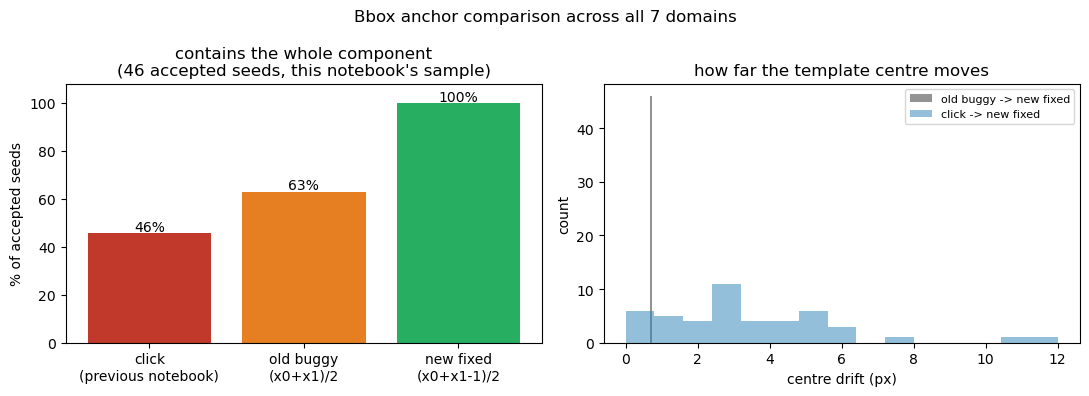

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

anchors = ["click_contains", "old_contains", "new_contains"]
anchor_labels = ["click\n(previous notebook)", "old buggy\n(x0+x1)/2", "new fixed\n(x0+x1-1)/2"]
pct = [100 * accepted_df[a].mean() for a in anchors]
colors = ["#c0392b", "#e67e22", "#27ae60"]
axes[0].bar(anchor_labels, pct, color=colors)
for i, p in enumerate(pct):
    axes[0].text(i, p + 1, f"{p:.0f}%", ha="center")
axes[0].set_ylim(0, 108)
axes[0].set_ylabel("% of accepted seeds")
axes[0].set_title(f"contains the whole component\n({len(accepted_df)} accepted seeds, this notebook's sample)")

axes[1].hist(accepted_df["drift_old_new"], bins=15, color="0.4", alpha=0.7, label="old buggy -> new fixed")
axes[1].hist(accepted_df["drift_click_new"], bins=15, color="#2980b9", alpha=0.5, label="click -> new fixed")
axes[1].set_xlabel("centre drift (px)")
axes[1].set_ylabel("count")
axes[1].set_title("how far the template centre moves")
axes[1].legend(fontsize=8)

fig.suptitle("Bbox anchor comparison across all 7 domains", fontsize=12)
plt.tight_layout()
plt.savefig("debug_pics/bbox_tuning_updated_anchor_summary.png", dpi=130)
plt.show()

## Where this goes next

- `midog_utils.seed_selection.build_seed` is the production entry point that calls
  `tightened_template_box` for new work (`D8_TEMPLATE_ANCHOR.md`) — it also applies the
  recentred-point border re-check the anchor change requires, which this notebook does not (it
  only checks geometric containment, not read-safety near the ROI edge).
- **Ground truth does not move.** `(cx, cy)` stays the click for `gt_eval` exclusion and every
  MIDOG match-radius computation in the real pipeline — only where the *template* is cut from
  changes.
- **This notebook shows mechanism, not outcome**, same caveat `D8_TEMPLATE_ANCHOR.md` makes
  explicit: a template that provably contains the whole validated component is not automatically
  a *better* template for matching. Whether the recentred anchor improves precision@K or
  recall@K over the click-centred one is a separate question, addressed (not by this
  notebook) in `production_seed_precision_at_k/*_half_pix_fix.ipynb`.
- The `method="multiotsu"` and `center_tolerance` options, and the largest-CC alternative, are
  untouched by this fix and are documented in the original `bbox_tuning_walkthrough.ipynb` and
  `Research Logs/design_choices.md`, sections 7/7a/7b.